<div style="background: #1f2933; padding: 30px; border-radius: 14px; text-align: center; color: #f9fafb; box-shadow: 0px 4px 12px rgba(0,0,0,0.15); border-left: 5px solid #85e0e9ff;">

<h1 style="margin-bottom: 10px;">
📊 Exercise project 4 – Support Vector Machines (SVM) DECISION TREE (PART-1)
</h1>

<h3 style="margin-top: 0; font-weight: 400; color: #fde68a;">
ML Model: Energy Consumption
</h3>

</div>



<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #85e0e9ff; width: fit-content;">

<h4 style="margin:0; color:#f9fafb;">
<b>Dataset name:</b>
</h4>

<a href="https://www.kaggle.com/datasets/govindaramsriram/energy-consumption-dataset-linear-regression" 
   target="_blank"
   style="font-size:16px; color:#fde68a; text-decoration:none;">
Energy Consumption Dataset 
</a>

</div>


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #85e0e9ff; width: fit-content;">

<h4 style="margin:0; color:#f9fafb;">
<b>Dataset format:</b>
</h4>

<p style="font-size:16px; color:#fde68a; text-decoration:none;">
    Single CSV
</p>

</div>


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #85e0e9ff; width: fit-content;">

  <h4 style="margin:0; color:#f9fafb;">
    <b>Data description</b>
  </h4>

  <p style="margin:10px 0 6px 0; font-size:16px; color:#fde68a;">
    This dataset is built for predicting building energy consumption. 
    Each row represents a building record with structural and environmental features that affect electricity usage.
  </p>

  <ul style="margin:6px 0 0 18px; padding:0; font-size:16px; color:#fde68a;">
    <li><b>Building Type</b></li>
    <li><b>Square Footage</b></li>
    <li><b>Number of Occupants</b></li>
    <li><b>Number of Appliances</b></li>
    <li><b>Average Temperature</b></li>
    <li><b>Day of Week</b></li>
    <li><b>Energy Consumption</b> (Target)</li>
  </ul>

</div>

<div style="background-color: #fff3cd; border: 2px solid #ffc107; padding: 15px; border-radius: 8px; margin: 20px 0;">
    <h3 style="color: #856404; margin-top: 0;">⚠️ Before You Start</h3>
    <p style="color: #856404; margin-bottom: 0;">
        <strong>Remember:</strong> Run each cell in order by clicking inside it and pressing <kbd>Shift</kbd> + <kbd>Enter</kbd>. Don't skip ahead!
    </p>
</div>

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #85e0e9ff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b>STEP 1 - Loading the dataset</b>
</h3>
<p style="font-size:16px; color:#fde68a; text-decoration:none;">
    Code: Importing modules, custom functions and loading the data
</p>
</div>


<h3>
<strong style='color:orange ;'> SVM Regression and AUTOMATIC SCALING
 </strong>
</h3>




In [1]:
# Loading the required modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# importing helpful features like pipelines etc, also SVM!
from sklearn.model_selection import train_test_split
from sklearn import metrics, svm
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# this module makes our life EASIER
# combine this with Pipelines => both X and y -scaling can be automated!
from sklearn.compose import TransformedTargetRegressor

# import seaborn as sns
from matplotlib import pyplot as plt
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier 
from sklearn import tree
import pandas as pd
import dtreeviz

In [2]:
# loading the data
df = pd.read_csv("test_energy_data.csv")
df


,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,24563,15,4,28.52,Weekday,2865.57
1,Commercial,27583,56,23,23.07,Weekend,4283.80
2,Commercial,45313,4,44,33.56,Weekday,5067.83
3,Residential,41625,84,17,27.39,Weekend,4624.30
4,Residential,36720,58,47,17.08,Weekday,4820.59
...,...,...,...,...,...,...,...
95,Commercial,1161,81,11,15.45,Weekend,3010.81
96,Residential,37943,50,23,21.73,Weekend,4248.49
97,Commercial,1558,27,29,16.86,Weekend,2843.60
98,Industrial,2145,56,12,11.77,Weekend,3348.39


---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #85e0e9ff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b> 🔬 STEP 2 - Exploring  the dataset</b>
</h3>
<p style="font-size:16px; color:#fde68a; text-decoration:none;">
   Code: Basic data checks, duplicates or missing values (NaN)?
</div>

In [3]:
# let's quickly see the first 5 rows of data
df.head(5)

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,24563,15,4,28.52,Weekday,2865.57
1,Commercial,27583,56,23,23.07,Weekend,4283.80
2,Commercial,45313,4,44,33.56,Weekday,5067.83
3,Residential,41625,84,17,27.39,Weekend,4624.30
4,Residential,36720,58,47,17.08,Weekday,4820.59


In [4]:
# printing total no.s of rows and columns of whole dataset
df.shape

(100, 7)

In [5]:
# checking column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        100 non-null    object 
 1   Square Footage       100 non-null    int64  
 2   Number of Occupants  100 non-null    int64  
 3   Appliances Used      100 non-null    int64  
 4   Average Temperature  100 non-null    float64
 5   Day of Week          100 non-null    object 
 6   Energy Consumption   100 non-null    float64
dtypes: float64(2), int64(3), object(2)
memory usage: 5.6+ KB


In [6]:
# getting statistical summary of the dataframe
df.describe()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,100.000000,100.000000,100.000000,100.000000,100.00000
mean,25881.920000,47.230000,26.970000,22.043300,4187.57830
std,13711.075264,29.905526,14.237846,6.957951,832.55985
min,1161.000000,2.000000,1.000000,10.400000,2351.97000
25%,14161.000000,21.000000,16.750000,15.682500,3621.92500
50%,27582.500000,47.000000,27.500000,21.970000,4249.39000
75%,38109.500000,73.000000,39.250000,27.492500,4797.17500
max,49354.000000,99.000000,49.000000,34.710000,6042.56000


---


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #85e0e9ff; width: fit-content;">

<h2 style="margin:0; color:#f9fafb;">
<b>Data Cleaning</b>
</h2>
</div>


<h3>
<strong style='color:orange ;'>Handling missing/duplicate values and 
HANDLE ALL CATEGORICAL VARIABLES CORRECTLY
 </strong>
</h3>




<h3>
<strong style='color:orange ;'>Data cleanup procedure and getting the ready data for training the Ml model
 </strong>
</h3>




In [7]:
# checking the nan values in the dataset
df.isna().sum()

Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64

In [8]:
# do we have duplicates in the dataset
duplicates = int(df.duplicated().sum())
duplicates

0

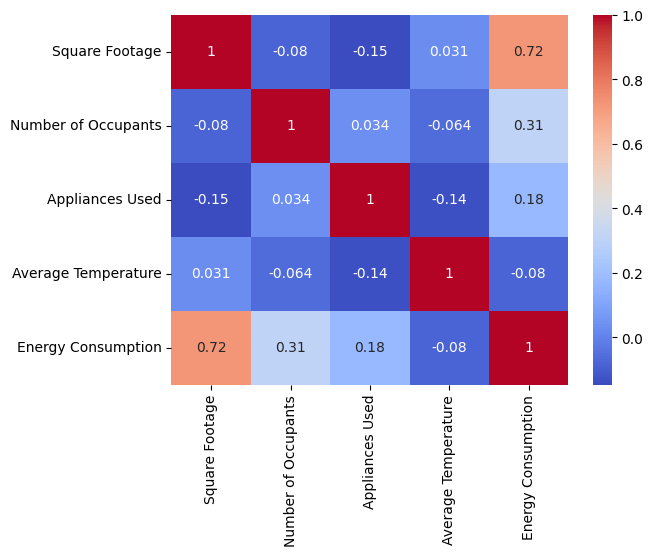

In [9]:
# Correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# plotting the correlation matrix using seaborn
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #85e0e9ff; width: fit-content;">

<h2 style="margin:0; color:#f9fafb;">
<b>Data Preparation</b>
</h2>
</div>


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #85e0e9ff; width: fit-content;">

<h4 style="margin:0; color:#f9fafb;">
<b> HANDLING ALL CATEGORICAL VARIABLES CORRECTLY</b>
</h4>
</div>


<h3>
<strong style='color:orange ;'>Case 1: Binary variables (only two options)
 </strong>
</h3>

In [10]:
# this just converts the value of column to 0 or 1
# factorize in pandas works too, but only one column at a time

from sklearn.preprocessing import LabelEncoder
variables = ['Day of Week']
encoder = LabelEncoder()
df[variables] = df[variables].apply(encoder.fit_transform)

<h3>
<strong style='color:orange ;'>Case 2: Ordinal variables (categories that have an order/rank -> can be compared)
</strong>
</h3>




In [11]:
# converting the categorical variable "Building Type" 
# to numerical values using mapping

cut_mapping = { "Residential": 1,
                "Industrial": 2,
                "Commercial": 3, 
                }

df['Building Type'] = df['Building Type'].map(cut_mapping)

<div style="border: 4px solid #85e0e9ff; padding: 10px 12px; background: #1f2933; margin: 10px 0; text-align: left; border-radius: 10px;">
  <h2 style="color: #f9fafb; margin: 0 0 8px 0; font-size: 2em; letter-spacing: 3px;">
    OBSERVATIONS:
  </h2>

  <ul style="margin: 0 0 12px 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li>There is only <b>one column</b> with <b>two unique values</b>, so I treated it as a <b>binary variable</b> and converted it into <b>0</b> and <b>1</b>.</li>
    <li>There is <b>one column</b> with <b>three distinct values</b>  so I treated it as an <b>ordinal variable</b> and mapped the categories into numbers.</li>
    <li>After these steps, all important columns are in <b>numeric format</b>, which is needed before training a machine learning model.</li>
  </ul>
</div>

---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #85e0e9ff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b> STEP 3: X/y and train/test - split</b>
</h3>
</div>


<h3 style='color:orange'>
  <b>Data preparation as X and Y</b>
</h3>


In [12]:
# first step, we split our data into SUPPORT variables and the TARGET variable
# X => support variables, y => target variable

# X => list of support variables the model uses 
# while predicting the target variable with the model
X = df.drop("Energy Consumption", axis=1)

# our target variable is y
y = df["Energy Consumption"]

In [13]:
print(y.unique())
print(sorted(y.unique()))

[2865.57 4283.8  5067.83 4624.3  4820.59 5026.23 4404.56 2394.37 3969.09
 5136.69 5162.33 3810.09 4400.48 4991.64 4474.98 2668.06 4987.52 4039.98
 3388.29 4068.94 4379.87 4921.73 5116.9  4656.29 5508.64 4205.35 4275.65
 4491.97 3999.14 3758.95 4779.08 4603.83 6042.56 3509.64 3598.87 4003.54
 4193.36 3908.   2405.34 5611.18 4789.37 3840.2  4897.66 4428.85 4276.25
 3506.64 5172.77 2731.87 3163.44 4149.12 3160.27 4294.59 5275.92 3072.63
 3629.61 5014.79 2998.47 4983.43 4707.07 2872.05 2351.97 5161.94 3562.43
 2725.89 5346.06 5446.   4575.58 4046.88 3039.52 3844.   4103.39 4721.39
 5334.33 4510.2  4009.8  3375.06 4618.77 4939.07 3112.64 4612.04 3980.9
 4374.35 4050.8  5900.32 3694.52 4652.65 5016.11 3127.82 5179.49 4001.96
 3451.58 3977.63 3830.68 4250.29 4137.66 3010.81 4248.49 2843.6  3348.39
 4722.59]
[np.float64(2351.97), np.float64(2394.37), np.float64(2405.34), np.float64(2668.06), np.float64(2725.89), np.float64(2731.87), np.float64(2843.6), np.float64(2865.57), np.float64(2872.05),

In [14]:
from sklearn.tree import DecisionTreeRegressor

# create a decision tree classifier for the visualization
# and train the model with our data
clf = DecisionTreeRegressor()
model = clf.fit(X, y)

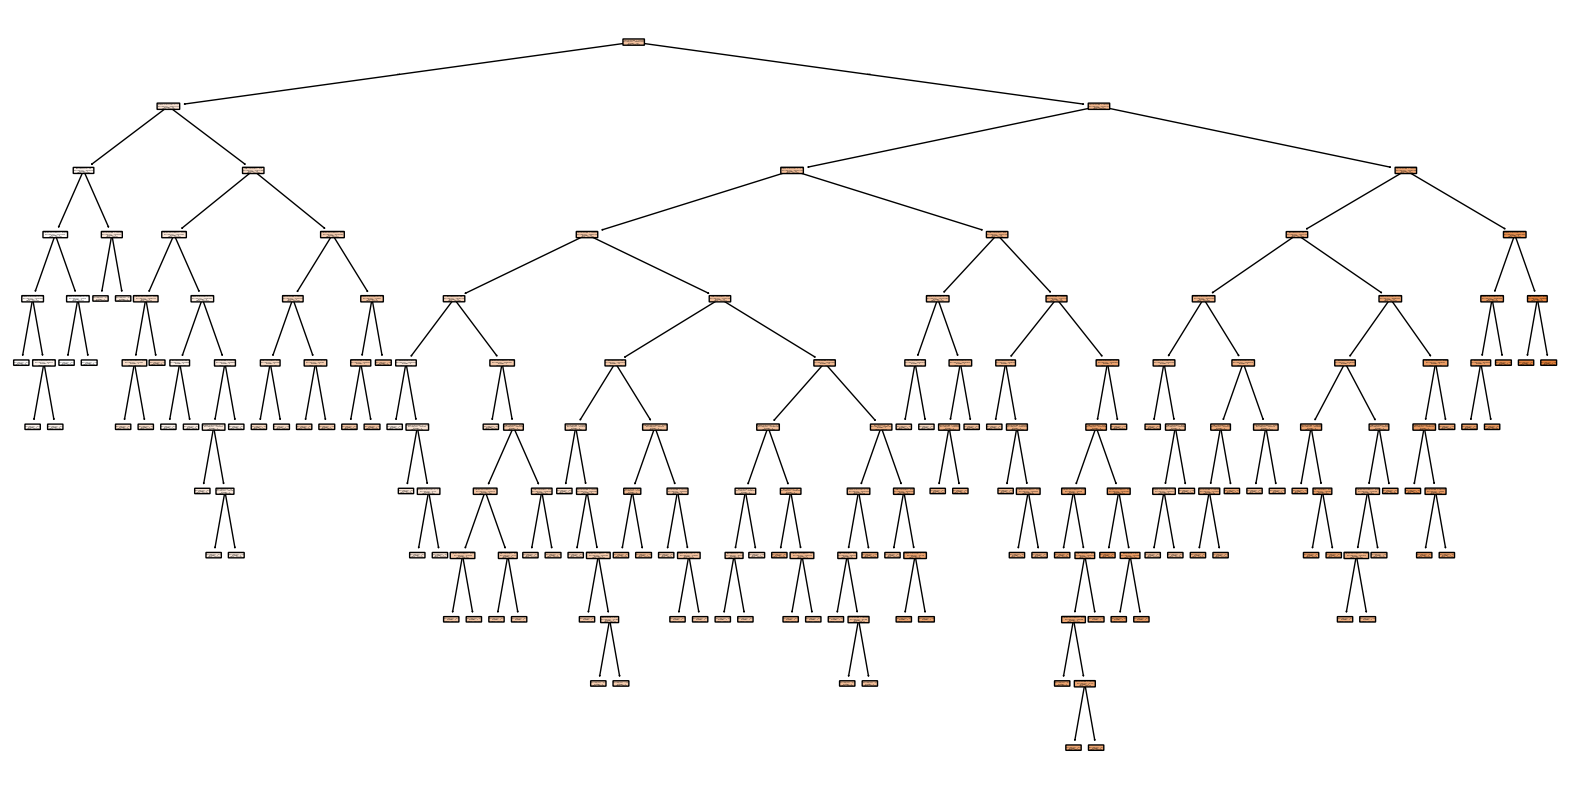

In [15]:
# visualize the decision tree
from sklearn.tree import export_graphviz
import subprocess
from sklearn import tree

# save the decision tree visualization into an svg-file

# NOTE! Always modify the class_names to match your data's TARGET VARIABLE OPTIONS
export_graphviz(clf, feature_names=X.columns, class_names=["No", "Yes"],    
                filled=True, rounded=True, node_ids=True, out_file="synthetic_asthma_tree.dot")

# # convert the DOT-file into SVG-file (which is supported by many tools
# subprocess.call(["dot", "-Tsvg", "synthetic_asthma_tree.dot", '-o', 'synthetic_asthma_sk.svg'])

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=X.columns, class_names=["No", "Yes"], filled=True, rounded=True)
plt.savefig("EC_test_sk.svg")
plt.show()

<h3>Version 2: Limit the amount of LEAVES in the tree (depth)</h3>

In [16]:
# visualize the decision tree
from sklearn.tree import export_graphviz
import subprocess
from sklearn import tree

# save the decision tree visualization into an svg-file
export_graphviz(clf, feature_names=X.columns, class_names=["No", "Yes"],
                filled=True, rounded=True, node_ids=True, out_file="EC_tree_limited.dot",
                max_depth=2)

# convert the DOT-file into SVG-file (which is supported by many tools
subprocess.call(["dot", "-Tsvg", "EC_tree_limited.dot", '-o', 'dt_EC_test_sk_limited.svg'])

0

In [17]:
# pip install dtreeviz
import dtreeviz

viz_model = dtreeviz.model(clf,
                           X_train=X, y_train=y,
                           feature_names=X.columns,
                           target_name="Decision",
                           class_names=["No", "Yes"])

# view in Jupyter notebook
# if decision tree is large, consider saving to .SVG -file
# and view with a web browser
viz_model.view(scale=1.5).save("dt_EC_test_sk_limited.svg")

/Users/SaadMahmood/Introduction-to-Machine-Learning-Methods/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names


In [18]:
print(y.dtype)
print(y.nunique())
print(y.unique())

float64
100
[2865.57 4283.8  5067.83 4624.3  4820.59 5026.23 4404.56 2394.37 3969.09
 5136.69 5162.33 3810.09 4400.48 4991.64 4474.98 2668.06 4987.52 4039.98
 3388.29 4068.94 4379.87 4921.73 5116.9  4656.29 5508.64 4205.35 4275.65
 4491.97 3999.14 3758.95 4779.08 4603.83 6042.56 3509.64 3598.87 4003.54
 4193.36 3908.   2405.34 5611.18 4789.37 3840.2  4897.66 4428.85 4276.25
 3506.64 5172.77 2731.87 3163.44 4149.12 3160.27 4294.59 5275.92 3072.63
 3629.61 5014.79 2998.47 4983.43 4707.07 2872.05 2351.97 5161.94 3562.43
 2725.89 5346.06 5446.   4575.58 4046.88 3039.52 3844.   4103.39 4721.39
 5334.33 4510.2  4009.8  3375.06 4618.77 4939.07 3112.64 4612.04 3980.9
 4374.35 4050.8  5900.32 3694.52 4652.65 5016.11 3127.82 5179.49 4001.96
 3451.58 3977.63 3830.68 4250.29 4137.66 3010.81 4248.49 2843.6  3348.39
 4722.59]


In [19]:
# # in order to limit the depth of the dtreeviz,
# # you have to create a separate classifier, with max depth

# # create a decision tree classifier for the visualization
# # and train the model with our data
# clf_limited = DecisionTreeClassifier(max_depth=4)
# model_limited = clf_limited.fit(X, y)

# # pip install dtreeviz
# import dtreeviz

# viz_model = dtreeviz.model(clf_limited,
#                            X_train=X, y_train=y,
#                            feature_names=X.columns,
#                            target_name="Decision",
#                            class_names=["No", "Yes"])

# # view in Jupyter notebook
# # if decision tree is large, consider saving to .SVG -file
# # and view with a web browser
# viz_model.view(scale=1.5).save("dt_EC_test_sk_limited.svg")
from sklearn.tree import DecisionTreeRegressor

# in order to limit the depth of the dtreeviz,
# you have to create a separate regressor, with max depth

# create a decision tree regressor for the visualization
# and train the model with our data
clf_limited = DecisionTreeRegressor(max_depth=4)
model_limited = clf_limited.fit(X, y)

# pip install dtreeviz
import dtreeviz

viz_model = dtreeviz.model(clf_limited,
                           X_train=X, y_train=y,
                           feature_names=X.columns.tolist(),
                           target_name="Decision")

# view in Jupyter notebook 
# if decision tree is large, consider saving to .SVG -file
# and view with a web browser
viz_model.view(scale=1.5).save("dt_EC_test_sk_limited.svg")

/Users/SaadMahmood/Introduction-to-Machine-Learning-Methods/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names


<h3 style='color:orange'>
  <b>Data is good to go (all numbers) => train model etc.
</b>
</h3>


In [20]:
# secondly, train/test -split with scikit-learn's helper function
# 0.3 for testing => 30% of data is reserved for testing purposes
# and based on that => it's deduced that 70% will be in the training data

# you can also define the random state, which is sometimes useful
# if you want to "lock down" all the randomness in order to get same results every time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

<div style="border: 4px solid #85e0e9ff; padding:14px 18px; background:#1f2933; margin:10px 0; border-radius:10px; width: fit-content;">

  <h2 style="color:#f9fafb; margin:0 0 8px 0; font-size:2em; letter-spacing:3px;">
     🔑 KEY INSIGHT: Training the X and the y split
  </h2>

  <p style="margin:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    I have used the 30 70 split for this model

  </p>

</div>

---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #85e0e9ff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b>STEP 4: Create and train the ML model</b>
</h3>
</div>


<h5 style='color:orange'>
  <b>NOTICE HERE! TransformedTargetRegressor automatically uses MinMaxScaler for y, and Pipeline automatically uses StandardScaler for X-variables => CONVENIENT!</b>
</h5>

<div style="border: 4px solid #85e0e9ff; padding:14px 18px; background:#1f2933; margin:10px 0; border-radius:10px; width: fit-content;">

  <h2 style="color:#f9fafb; margin:0 0 8px 0; font-size:2em; letter-spacing:3px;">
    CODE INSIGHT: 
  </h2>

  <ul style="margin:0 0 0 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li>I used PolynomialFeatures because there were some outliers after training.</li>
  </ul>

</div>

In [22]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn import svm

# pipeline: polynomial -> scaling -> SVR
pipeline = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    svm.LinearSVR()
)

# scale y automatically
model = TransformedTargetRegressor(
    regressor=pipeline,
    transformer=MinMaxScaler()
)

# train model
model.fit(X_train, y_train)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...LinearSVR())])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",MinMaxScaler()
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",None
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",None
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True


---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #85e0e9ff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b> STEP 5: Error and performance metrics</b>
</h3>
</div>


In [23]:
# we need to create test predictions based on our earlier reserved test dataset
# this data has never been seen by the model by now

# THESE PREDICTIONS ARE IN SCALED FORMAT
predictions = model.predict(X_test)

In [24]:
# MAE = Mean average error
mae = metrics.mean_absolute_error(y_test, predictions)
print("MAE:")
print(f"{round(mae, 2)}")

# MSE = Mean squared error
mse = metrics.mean_squared_error(y_test, predictions)
print("\nMSE:")
print(f"{round(mse, 2)} ^2")

# RMSE = Root Mean Squared Error
rmse = np.sqrt(mse)
print("\nRMSE:")
print(f"{round(rmse, 2)}")

# R-square (or R2) - how well the model describes the original dataset
# 1 => model describes the data perfectly
# 0 => model doesn't describe the data at all
r2 = metrics.r2_score(y_test, predictions)
print("\nR-squared:")
print(f"{round(r2, 2)}")

# THIS IS COMPLETELY OPTIONAL, but it's nice to see a relative as well
# (between 0.0 - 1.0)
# SCALED VERSIONS OF THE METRICS, only use MAE and RMSE
y_test_scaled = model.transformer_.transform(y_test.values.reshape(-1, 1)).ravel()
predictions_scaled = model.transformer_.transform(predictions.reshape(-1, 1)).ravel()

# calculate scaled MAE and RMSE
mae_scaled = metrics.mean_absolute_error(y_test_scaled, predictions_scaled)
rmse_scaled = np.sqrt(metrics.mean_squared_error(y_test_scaled, predictions_scaled))

print(f"\nMAE scaled: {round(mae_scaled, 2)}")
print(f"\nRMSE scaled: {round(rmse_scaled, 2)}")

MAE:
0.16

MSE:
0.04 ^2

RMSE:
0.19

R-squared:
1.0

MAE scaled: 0.0

RMSE scaled: 0.0


/var/folders/yy/4vrmj46n0_53mpnmp8clw2fh0000gn/T/ipykernel_3558/2920752686.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751



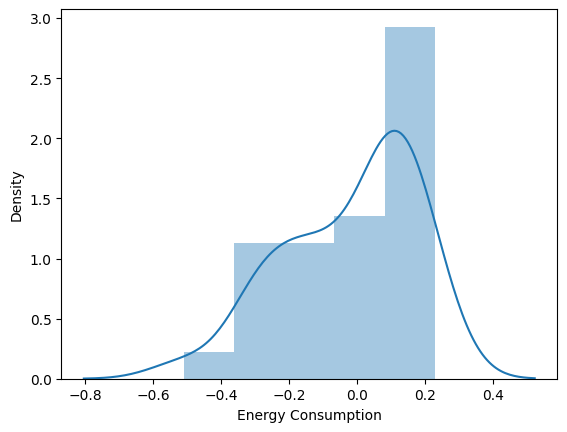

In [25]:
# if the prediction distribution is far from standard normal distritbuion
# then the model is not probably good enough
# distplot is deprecated and will be removed in future seaborn versions
# but not direct replacement has been created so far
sns.distplot((y_test - predictions))
plt.show()
plt.close()

<div style="border: 4px solid #85e0e9ff; padding:14px 18px; background:#1f2933; margin:10px 0; border-radius:10px; width: fit-content;">

  <h2 style="color:#f9fafb; margin:0 0 8px 0; font-size:2em; letter-spacing:3px;">
    OBSERVATION
  </h2>

  <ul style="margin:0 0 0 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li><b>R Squared is 1.0.</b> Which is very nice. The predictions are extremely close to the real values.</li>
    
    The scatter plot shows perfect diagonal line. This confirms that predictions match the actual values closely.
    The error distribution looks centered around zero and roughly normal. This means the model is not consistently predicting too high or too low.
    Overall, the model performance looks extremely good.
  </ul>

</div>

---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #85e0e9ff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b> STEP 6: Testing/using the model in practice (inference)</b>
</h3>
</div>


In [26]:
# creating a test row for prediction

test_building_type = "1"
test_square_footage = 24563
test_num_occupants = 15
test_appliances_used = 4
test_avg_temperature = 28.52
test_day_of_week = "0"

tester_row = {
    "Building Type": test_building_type,
    "Square Footage": test_square_footage,
    "Number of Occupants": test_num_occupants,
    "Appliances Used": test_appliances_used,
    "Average Temperature": test_avg_temperature,
    "Day of Week": test_day_of_week
}
# convert to pandas format
tester_row = pd.DataFrame([tester_row])

<h5 style='color:orange'>
  <b>NOTICE! No need to invert any scalings, since Pipeline + TransformedTargetRegressor scale everything automatically!</b>
</h5>

In [27]:
# get prediction from model
result = model.predict(tester_row)[0]

print()
print("Predicted Energy Consumption:")
print(f"{round(float(result), 2)} kWh")
print("----------------------------")


Predicted Energy Consumption:
2865.68 kWh
----------------------------


---


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #85e0e9ff; width: fit-content;">

<h1 style="margin:0; color:#f9fafb;">
<b>AI USAGE:</b>
</h1>
</div>


<h3 style='color:orange'>
  <b>Markdown styles</b>
</h3>

---


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #85e0e9ff; width: fit-content;">

<h1 style="margin:0; color:#f9fafb;">
<b>Ideas for further improvements:</b>
</h1>
</div>


<h5 style='color:orange'>
  <b>Have more rows and columns</b>
</h5>

---

<div style="border: 4px solid #85e0e9ff; padding:14px 18px; background:#1f2933; margin:10px 0; border-radius:10px; width: fit-content;">

  <h2 style="color:#f9fafb; margin:0 0 8px 0; font-size:2em; letter-spacing:3px;">
    CONCLUSION
  </h2>

  <p style="margin:0 0 8px 0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    The decision tree predicts <b>building energy consumption in kWh</b> based on <b>six input features</b>. <b>Square Footage</b> is the most important feature of the model's decisions. <b>Number of Occupants</b> follows the next after (SF) <b>Day of Week</b> does not appears in any of the nodes leaves and the tree never uses it in any split.
  </p>

  <p style="margin:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    The SVM model scores <b>R² of 1.0</b> on the test data. <b>MAE and RMSE are low</b>, meaning the average prediction error is small. The scatter plot confirms predictions sit close to the actual values across the full range.
  </p>

</div>

---